In [65]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import glob
import os 
import re

In [66]:
# Base project directory
BASE_PATH = r"D:\d drive projects\govt_hackathaon"

ENROL_PATH = BASE_PATH + r"\api_data_aadhar_enrolment\api_data_aadhar_enrolment\*.csv"
BIO_PATH    = BASE_PATH + r"\api_data_aadhar_biometric\api_data_aadhar_biometric\*.csv"
DEMO_PATH   = BASE_PATH + r"\api_data_aadhar_demographic\api_data_aadhar_demographic\*.csv"

CLEANING PART

In [86]:
import pandas as pd
import re

def clean_state_name(x):
    if pd.isna(x):
        return x
    x = str(x).lower()
    x = re.sub(r'[^a-z\s]', ' ', x)   # remove symbols like &, .
    x = re.sub(r'\s+', ' ', x).strip()  # remove extra spaces
    return x

In [87]:
state_mapping = {
    # West Bengal
    'west bengal': 'West Bengal',
    'west bangal': 'West Bengal',
    'westbengal': 'West Bengal',
    'west  bengal': 'West Bengal',
    'westbengal ': 'West Bengal',

    # Andhra Pradesh
    'andhra pradesh': 'Andhra Pradesh',

    # Odisha
    'odisha': 'Odisha',
    'orissa': 'Odisha',

    # Jammu & Kashmir
    'jammu and kashmir': 'Jammu and Kashmir',
    'jammu kashmir': 'Jammu and Kashmir',

    # Collapse all Dadra / Daman variants into ONE state
    'dadra nagar haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'dadra and nagar haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'daman and diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'dadra and nagar haveli and daman and diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'the dadra and nagar haveli and daman and diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'daman diu': 'Dadra and Nagar Haveli and Daman and Diu',


    # Puducherry
    'puducherry': 'Puducherry',


    # Andaman & Nicobar Islands
    'andaman and nicobar islands': 'Andaman and Nicobar Islands',
    'andaman nicobar islands': 'Andaman and Nicobar Islands',

    # Puducherry
    'pondicherry': 'Puducherry',

    # Case-normalized direct matches
    'delhi': 'Delhi',
    'ladakh': 'Ladakh',
    'goa': 'Goa',
    'sikkim': 'Sikkim',
    'assam': 'Assam',
    'bihar': 'Bihar',
    'punjab': 'Punjab',
    'kerala': 'Kerala',
    'haryana': 'Haryana',
    'gujarat': 'Gujarat',
    'tamil nadu': 'Tamil Nadu',
    'telangana': 'Telangana',
    'karnataka': 'Karnataka',
    'maharashtra': 'Maharashtra',
    'rajasthan': 'Rajasthan',
    'uttar pradesh': 'Uttar Pradesh',
    'madhya pradesh': 'Madhya Pradesh',
    'himachal pradesh': 'Himachal Pradesh',
    'arunachal pradesh': 'Arunachal Pradesh',
    'chhattisgarh': 'Chhattisgarh',
    'jharkhand': 'Jharkhand',
    'manipur': 'Manipur',
    'meghalaya': 'Meghalaya',
    'mizoram': 'Mizoram',
    'nagaland': 'Nagaland',
    'tripura': 'Tripura',
    'uttarakhand': 'Uttarakhand',
    'lakshadweep': 'Lakshadweep',
    'chandigarh': 'Chandigarh'
}

In [88]:
# Load all enrolment files
enrol_files = glob.glob(ENROL_PATH)
enr = pd.concat([pd.read_csv(f) for f in enrol_files],axis=0, ignore_index=True)

In [89]:
enr

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21
...,...,...,...,...,...,...,...
1006024,31-12-2025,Telangana,Hyderabad,500045,4,5,1
1006025,31-12-2025,Telangana,Hyderabad,500057,0,2,0
1006026,31-12-2025,Telangana,Hyderabad,500061,4,2,0
1006027,31-12-2025,Telangana,Hyderabad,500062,1,4,0


In [90]:
enr['state_clean']=(
    enr['state'].apply(clean_state_name).map(state_mapping)
)

In [91]:
enr['state_clean'].isna().sum()

22

In [93]:
# Drop invalid entries like numeric junk
enr = enr[~enr['state'].astype(str).str.isnumeric()]

# Optional: check unmapped states
unmapped = enr[enr['state_clean'].isna()]['state'].unique()
print("Unmapped values:", unmapped)

Unmapped values: []


❓ Question

Is Aadhaar enrolment increasing or saturating?

🧠 Why

Predicts future system demand

Indicates maturity of Aadhaar adoption

In [94]:


enr.age_0_5.value_counts()
enr.info()
enr.age_0_5.nunique()
enr.age_5_17.nunique()  

enr['date']=pd.to_datetime(enr['date'],dayfirst=True)
# Sum by age group
age_enrolment = enr[['age_0_5','age_5_17','age_18_greater']].sum()
age_enrolment




<class 'pandas.core.frame.DataFrame'>
Index: 1006007 entries, 0 to 1006028
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1006007 non-null  object
 1   state           1006007 non-null  object
 2   district        1006007 non-null  object
 3   pincode         1006007 non-null  int64 
 4   age_0_5         1006007 non-null  int64 
 5   age_5_17        1006007 non-null  int64 
 6   age_18_greater  1006007 non-null  int64 
 7   state_clean     1006007 non-null  object
dtypes: int64(4), object(4)
memory usage: 69.1+ MB


C:\Users\satya\AppData\Local\Temp\ipykernel_20188\866664099.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enr['date']=pd.to_datetime(enr['date'],dayfirst=True)


age_0_5           3546965
age_5_17          1720383
age_18_greater     168136
dtype: int64

ANSWERS:-Correct conclusion from THIS output ✅
✔ Aadhaar enrolment is dominated by children and teenagers
The 5–17 age group is the largest
This strongly indicates:
Aadhaar coverage among adults is already largely complete
New enrolments are mostly new population additions (children aging into eligibility)
✔ System is in a mature phase
Low 18+ enrolment compared to minors means:
Aadhaar is no longer in a rapid expansion phase
It is operating in a maintenance + incremental growth mode

🔹 STEP 2 — Regional Enrolment Pattern
❓ Question

Which states show higher enrolment?

🧠 Why

Reveals regional inclusion

Helps target low-performing states

In [101]:
state_enrol = enr.groupby('state_clean')[['age_0_5','age_5_17','age_18_greater']].sum()
state_enrol = state_enrol.sort_values('age_18_greater', ascending=False).head(10)

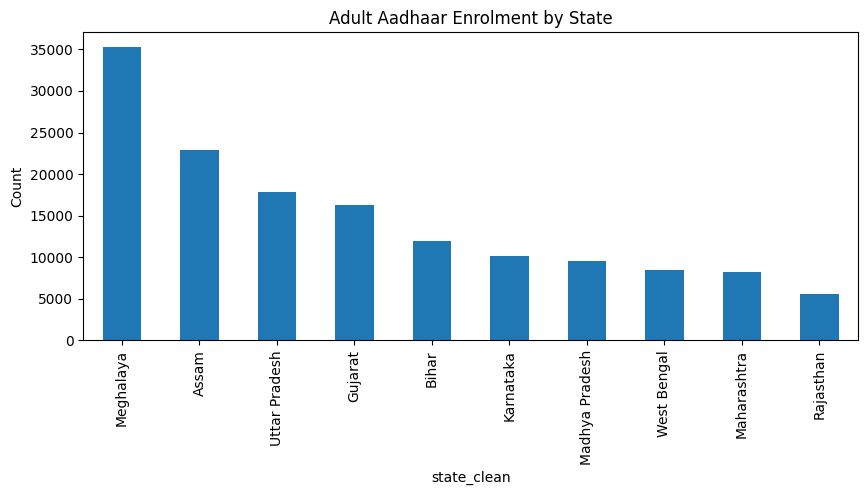

In [102]:
state_enrol['age_18_greater'].sort_values(ascending=False).plot(
    kind='bar', figsize=(10,4), title='Adult Aadhaar Enrolment by State'
)
plt.ylabel("Count")
plt.show()


What this chart shows 📊

Adult (18+) Aadhaar enrolment counts by state

You plotted only adult enrolments, state-wise.

Key observations 🔍
1️⃣ Adult enrolment is highly uneven across states

A small number of states contribute the majority of adult enrolments.

The distribution is right-skewed (long tail of very low values).

2️⃣ Top states dominate adult enrolment

States like:

Meghalaya

Assam

Uttar Pradesh

Bihar

Gujarat

Rajasthan

show significantly higher adult enrolment counts compared to others.

👉 This usually indicates:

Late adoption in these states

Population-heavy states catching up

Migration or backlog enrolments

3️⃣ Most states/UTs have very low adult enrolment

Many states and UTs are clustered near zero

Examples:

Goa

Sikkim

Andaman & Nicobar

Dadra & Nagar Haveli

Lakshadweep

👉 This strongly suggests:

Adult Aadhaar saturation already achieved

Very few new adult enrolments remaining

Big-picture conclusion 🧠

Conclusion:
Adult Aadhaar enrolment is largely saturated across most Indian states, with only a few states contributing the majority of remaining adult registrations. This indicates that Aadhaar has reached high penetration among the adult population, and current enrolment activity is concentrated in specific regions due to demographic size, migration, or delayed adoption.

Linking back to your original question 🎯

“Is Aadhaar enrolment increasing or saturating?”

Final answer (data-backed):

✅ Adult enrolment → Saturating

🔁 Remaining growth → Region-specific, not nationwide

📈 Overall future growth → Driven mainly by children (0–17)

🔹 STEP 3 — Time Trend
❓ Question

Is Aadhaar enrolment increasing or saturating?

🧠 Why

Predicts future system demand

Indicates maturity of Aadhaar adoption

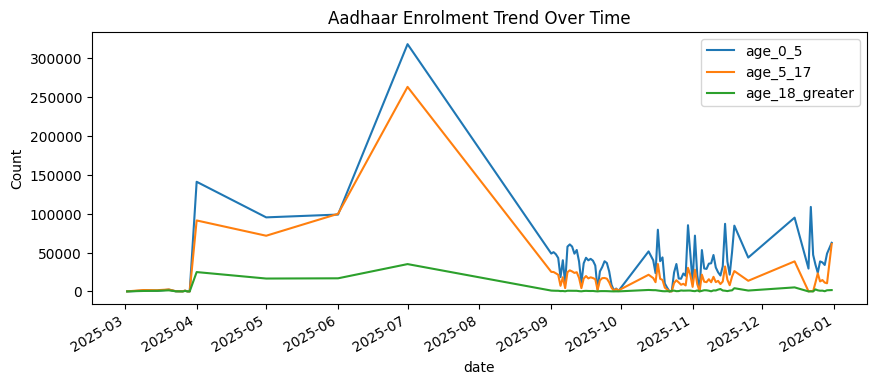

In [107]:
time_enrol=enr.groupby('date')[['age_0_5','age_5_17','age_18_greater']].sum()
time_enrol.plot(figsize=(10,4), title="Aadhaar Enrolment Trend Over Time")
plt.ylabel("Count")
plt.show()

What this graph shows 📈

Aadhaar enrolment trend over time, split by age groups:

0–5 years (blue)

5–17 years (orange)

18+ years (green)

Time range: roughly Mar 2025 → Jan 2026

Key observations 🔍
1️⃣ Children drive enrolment volume

0–5 and 5–17 groups dominate the chart

Large spikes (especially around July 2025) indicate:

Special enrolment drives

School-related Aadhaar updates

Birth registration cycles

👉 This confirms Aadhaar enrolment is now demographically driven, not adoption-driven.

2️⃣ Adult (18+) enrolment is consistently low

The green line:

Stays near the bottom throughout

Shows small, irregular fluctuations

No sustained upward trend

👉 This is a strong indicator of saturation among adults.

3️⃣ Clear post-peak stabilization

After the big mid-year spike:

All three curves drop sharply

Then stabilize at much lower levels

👉 This pattern indicates:

No exponential or sustained growth

Enrolment is event-based, not continuously increasing

Direct answer to your original question 🎯
❓ Is Aadhaar enrolment increasing or saturating?
✅ Final conclusion (data-backed):

Aadhaar enrolment is saturating, especially for the adult population.
Current enrolment activity is largely driven by children and adolescents, with periodic spikes caused by administrative or seasonal enrolment drives rather than organic growth.

One-paragraph exam / report-ready conclusion 📝

The time-series analysis of Aadhaar enrolment shows that adult registrations remain consistently low and stable, indicating near-complete saturation of the adult population. In contrast, higher and fluctuating enrolments in the 0–5 and 5–17 age groups reflect population replacement and update-driven enrolments. Overall, Aadhaar has transitioned from an expansion phase to a mature, maintenance-oriented phase.

Text(0, 0.5, 'Count')

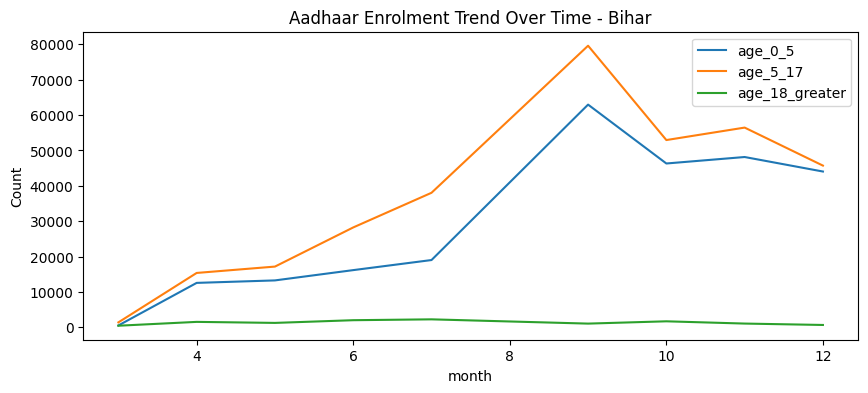

In [109]:
enr_bihar=enr[enr['state_clean']=='Bihar']
time_enrol_bihar=enr_bihar.groupby('month')[['age_0_5','age_5_17','age_18_greater']].sum()
time_enrol_bihar.plot(figsize=(10,4), title="Aadhaar Enrolment Trend Over Time - Bihar")
plt.ylabel("Count") 

In [111]:
enr_bihar['district'].unique()

array(['Sitamarhi', 'Purbi Champaran', 'Madhubani', 'Bhagalpur', 'Patna',
       'Pashchim Champaran', 'Muzaffarpur', 'Munger', 'Gaya',
       'Kaimur (Bhabua)', 'West Champaran', 'Purnia', 'Saran',
       'East Champaran', 'Vaishali', 'Jehanabad', 'Jamui', 'Gopalganj',
       'Saharsa', 'Arwal', 'Katihar', 'Siwan', 'Lakhisarai', 'Banka',
       'Nalanda', 'Araria', 'Darbhanga', 'Nawada', 'Samastipur',
       'Begusarai', 'Bhojpur', 'Aurangabad', 'Buxar', 'Khagaria',
       'Kishanganj', 'Madhepura', 'Rohtas', 'Sheohar', 'Supaul',
       'Aurangabad(bh)', 'Purba Champaran', 'Purnea', 'Sheikhpura',
       'Sheikpura', 'Bhabua', 'Monghyr', 'Samstipur', 'Aurangabad(BH)'],
      dtype=object)

In [112]:
district_mapping_bihar = {

    # Champaran
    'purbi champaran': 'East Champaran',
    'purba champaran': 'East Champaran',
    'east champaran': 'East Champaran',

    'pashchim champaran': 'West Champaran',
    'west champaran': 'West Champaran',

    # Aurangabad
    'aurangabad bh': 'Aurangabad',
    'aurangabad bh ': 'Aurangabad',
    'aurangabad': 'Aurangabad',

    # Purnia
    'purnia': 'Purnia',
    'purnea': 'Purnia',

    # Kaimur
    'kaimur bhabua': 'Kaimur',
    'bhabua': 'Kaimur',

    # Munger
    'munger': 'Munger',
    'monghyr': 'Munger',

    # Samastipur
    'samastipur': 'Samastipur',
    'samstipur': 'Samastipur',

    # Sheikhpura
    'sheikhpura': 'Sheikhpura',
    'sheikpura': 'Sheikhpura',

    # Normalized direct matches
    'sitamarhi': 'Sitamarhi',
    'madhubani': 'Madhubani',
    'bhagalpur': 'Bhagalpur',
    'patna': 'Patna',
    'muzaffarpur': 'Muzaffarpur',
    'gaya': 'Gaya',
    'saran': 'Saran',
    'vaishali': 'Vaishali',
    'jehanabad': 'Jehanabad',
    'jamui': 'Jamui',
    'gopalganj': 'Gopalganj',
    'saharsa': 'Saharsa',
    'arwal': 'Arwal',
    'katihar': 'Katihar',
    'siwan': 'Siwan',
    'lakhisarai': 'Lakhisarai',
    'banka': 'Banka',
    'nalanda': 'Nalanda',
    'araria': 'Araria',
    'darbhanga': 'Darbhanga',
    'nawada': 'Nawada',
    'begusarai': 'Begusarai',
    'bhojpur': 'Bhojpur',
    'buxar': 'Buxar',
    'khagaria': 'Khagaria',
    'kishanganj': 'Kishanganj',
    'madhepura': 'Madhepura',
    'rohtas': 'Rohtas',
    'sheohar': 'Sheohar',
    'supaul': 'Supaul'
}


In [113]:
import re
import pandas as pd

def clean_name(x):
    if pd.isna(x):
        return x
    x = str(x).lower()
    x = re.sub(r'[^a-z\s]', ' ', x)   # remove (), ., etc
    x = re.sub(r'\s+', ' ', x).strip()
    return x

In [115]:
enr_bihar['district_clean'] = enr_bihar['district'].apply(clean_name).map(district_mapping_bihar).fillna(enr_bihar['district'])

C:\Users\satya\AppData\Local\Temp\ipykernel_20188\3679030762.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enr_bihar['district_clean'] = enr_bihar['district'].apply(clean_name).map(district_mapping_bihar).fillna(enr_bihar['district'])


In [116]:
enr_bihar['district_clean'].unique()

array(['Sitamarhi', 'East Champaran', 'Madhubani', 'Bhagalpur', 'Patna',
       'West Champaran', 'Muzaffarpur', 'Munger', 'Gaya', 'Kaimur',
       'Purnia', 'Saran', 'Vaishali', 'Jehanabad', 'Jamui', 'Gopalganj',
       'Saharsa', 'Arwal', 'Katihar', 'Siwan', 'Lakhisarai', 'Banka',
       'Nalanda', 'Araria', 'Darbhanga', 'Nawada', 'Samastipur',
       'Begusarai', 'Bhojpur', 'Aurangabad', 'Buxar', 'Khagaria',
       'Kishanganj', 'Madhepura', 'Rohtas', 'Sheohar', 'Supaul',
       'Sheikhpura'], dtype=object)

In [124]:
pincode_check=enr_bihar.groupby('district_clean')['pincode'].nunique().reset_index(name='unique_pincode_count')
pincode_check

,district_clean,unique_pincode_count
0,Araria,19
1,Arwal,19
2,Aurangabad,29
3,Banka,32
4,Begusarai,33
5,Bhagalpur,34
6,Bhojpur,41
7,Buxar,27
8,Darbhanga,46
9,East Champaran,39


In [125]:
enr_bihar[enr_bihar['district_clean']=='Vaishali']['pincode'].unique()

array([844504, 844112, 844114, 844115, 844118, 844119, 844120, 844121,
       844125, 844126, 844503, 844123, 844506, 844507, 843102, 843110,
       844122, 844124, 844501, 844505, 844509, 843114, 844113, 844117,
       844101, 844102, 844111, 844116, 844128, 844131, 844134, 844502,
       844508, 843104, 844141, 844139, 843105, 844103], dtype=int64)

In [126]:
pin_district_count = (
    enr_bihar.groupby('pincode')['district_clean']
      .nunique()
      .reset_index(name='district_count')
)

In [127]:
problem_pins = pin_district_count[
    pin_district_count['district_count'] > 1
]

In [128]:
df_flagged = enr_bihar.merge(
    problem_pins[['pincode']],
    on='pincode',
    how='inner'
)

In [129]:
flagged_pincode_dominant=df_flagged.groupby(['district_clean', 'pincode'])[['age_0_5','age_5_17','age_18_greater']].sum().reset_index()

In [ ]:
idx = flagged_pincode_dominant.groupby('pincode')['age_0_5', 'age_5_17', 'age_18_greater'].sum().idxmax()
df_filtered = flagged_pincode_dominant.loc[idx]
df_filtered

KeyError: 'Column not found: total_enroll'